

## Implementation of an Additive Source

Implementing a source by strictly defining a field component is not optimal, because the node with the source behaves like a short circuit, and electromagnetic energy cannot propagate through such a source. This problem can be solved by introducing an *additive source* of the electromagnetic field, which does not prevent the propagation of energy.

For the derivation, we can start from **Ampère’s law with current density**, which has the form

\begin{equation*}
\nabla \times \mathbf{H} = \mathbf{J} + \epsilon \frac{\partial \mathbf{E}}{\partial t}
\end{equation*}

### Explanation of variables
- \(\nabla \times \mathbf{H}\) — curl of the magnetic field intensity **H**.  
- \(\mathbf{J}\) — current density vector (movement of charge carriers and currents from other sources).  
- \(\epsilon\) — permittivity of the medium.  
- \(\dfrac{\partial \mathbf{E}}{\partial t}\) — time derivative of the electric field intensity **E**.

The current density \(\mathbf{J}\) represents both the motion of charge carriers under the influence of the electric field and currents associated with other sources in the medium.

After rearranging, we obtain

\begin{equation*}
\frac{\partial \mathbf{E}}{\partial t} = \frac{1}{\epsilon} \nabla \times \mathbf{H} - \frac{1}{\epsilon} \mathbf{J}
\end{equation*}

### Interpretation
- \(\dfrac{1}{\epsilon} \nabla \times \mathbf{H}\) — contribution from the magnetic field.  
- \(-\dfrac{1}{\epsilon} \mathbf{J}\) — contribution from the source current density.





By converting into the differential form and rearranging into the update equation, we obtain  

\begin{equation}
E_z^{q+1}[m] = E_z^{q}[m] + \frac{\Delta t}{\epsilon \, \Delta x} \big( H_y^{q + 1/2}[m + 1/2] - H_y^{q+1/2}[m-1/2] \big) - \frac{\Delta t}{ \epsilon} J_z^{q+1/2}[m]
\end{equation}

To avoid having to modify the implementation from the previous chapter, we split the update into two steps:  

\begin{align}
E_z^{q+1}[m] &= E_z^{q}[m] + \frac{\Delta t}{\epsilon \, \Delta x} \big( H_y^{q + 1/2}[m + 1/2] - H_y^{q+1/2}[m-1/2] \big) \\
E_z^{q+1}[m] &= E_z^{q}[m] - \frac{\Delta t}{ \epsilon} J_z^{q+1/2}[m]
\end{align}




## Boundary Conditions for the Simulation of an Unbounded Medium

In the previous examples, the boundary conditions represented fictitious ideal electric (PEC) or magnetic (PMC) conductors, where reflections occurred at the boundary of the medium. For the simulation of EM energy propagation in space, it is more suitable — when using a finite number of nodes — to define the conditions so that the medium can be considered unbounded, i.e., no reflections occur at the boundary of the region.  

In the one-dimensional case, with Courant number \(S_c = 1\), such conditions can be defined exactly (ABC – Absorbing Boundary Condition). For other cases, an approximation is necessary.  

The ABC for the left boundary can be derived from a simple reasoning. Since we require the energy to propagate exclusively from right to left, and we also assume that no energy will propagate into the medium from outside, the updated value of \(E_z[0]\) must equal the pre-update value of \(E_z[1]\), i.e.,  

\begin{equation*}
E_z[0] = E_z[1]
\end{equation*}

Similarly, for the right boundary:  

\begin{equation*}
H_y[nodes-1] = H_y[nodes-2]
\end{equation*}

This form of boundary conditions is valid only in a simple one-dimensional case, and it is clear that they depend on the order of field component updates in the simulation step.  

---

### Explanation of variables
- \(E_z\) — electric field component along the **z-axis**  
- \(H_y\) — magnetic field component along the **y-axis**  
- `nodes` — total number of spatial grid points (discretization in space)  
- \(S_c\) — Courant number, stability parameter defined as  
  \[
  S_c = \frac{c \, \Delta t}{\Delta x}
  \]  
  where \(c\) is the speed of light, \(\Delta t\) is the time step, and \(\Delta x\) is the spatial step.  


In [3]:
import matplotlib.pyplot as plt

def tm_plot(times, r):
    """
    Plot Ez field snapshots at selected time steps.

    Parameters
    ----------
    times : list of int
        Time steps to plot.
    r : ndarray
        2D array of shape (time, nodes) containing Ez values.
    """
    plt.figure(figsize=(10, 6))

    for i, t in enumerate(times):
        plt.subplot(len(times), 1, i + 1)
        plt.plot(r[t, :], "r-")
        plt.ylim(-1.1, 1.1)
        plt.xlim(0, r.shape[1])
        plt.legend([f"t={t}"])
        plt.grid(True)

    plt.tight_layout()
    plt.show()


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def wv_plot(time, nodes, r):
    """
    Plot a wave propagation diagram over time and space.
    
    Parameters:
    - time: number of time steps
    - nodes: number of spatial nodes
    - r: 2D array (time x nodes) containing Ez values
    """
    plt.figure(figsize=(10, 6))
    
    # Normalize for better visualization
    r_norm = r / np.max(np.abs(r))
    
    # Plot each time step offset for a "stacked" wave effect
    for t in range(0, time, int(time/20)):
        plt.plot(r_norm[t, :] + t * 0.05, label=f"t={t}")
    
    plt.xlabel("X")
    plt.ylabel("Amplitude + Time offset")
    plt.title("Wave propagation over time")
    plt.grid(True)
    plt.show()

# Example usage with your generated array `r`
nodes = 200
time = 200
# Assuming `r` is already filled with Ez values from your simulation
# wv_plot(time, nodes, r)


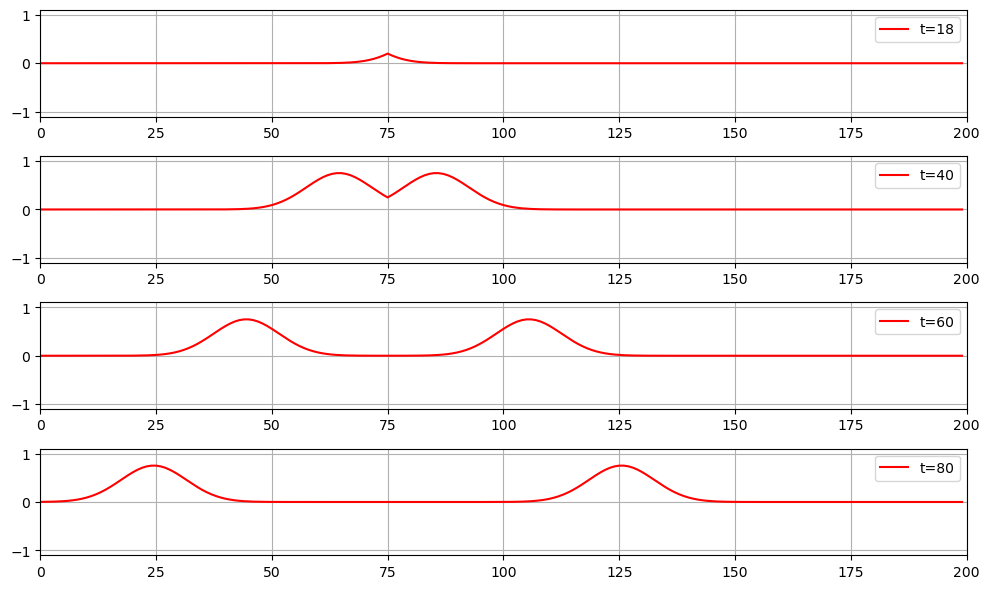

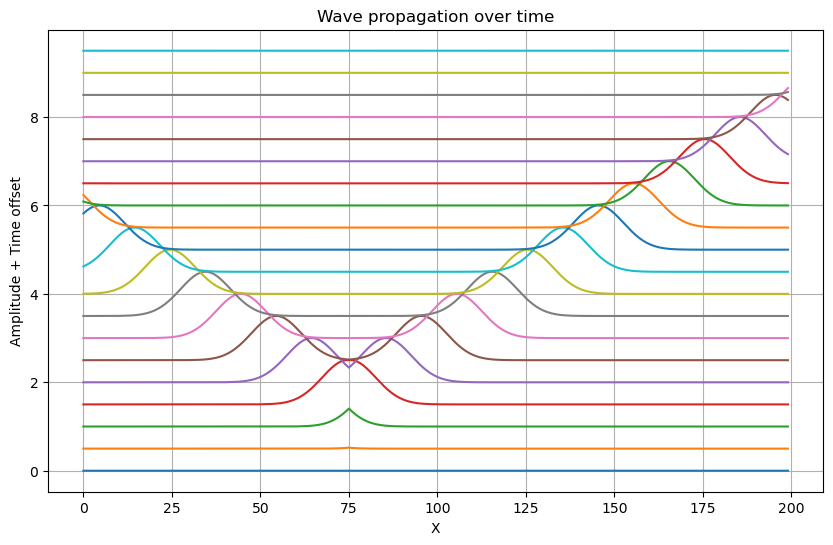

In [9]:

%matplotlib inline
from scipy import *
#from utils.utils import *
import matplotlib.pyplot as plt
import numpy as np

nodes = 200
time = 200
ez = np.zeros(nodes)
hy = np.zeros(nodes)
z0 = 377.0

r = np.zeros((time, nodes))                             # pole vysledkov

for t in range(time):
    ez[0] = ez[1]
    for m in range(1,nodes):                         # 0...199
        ez[m] = ez[m] + (hy[m] - hy[m - 1]) * z0     # aktualizacia Ez
    ez[75] += np.exp(-(t - 30.)**2 / 100.)*1.5             # zdroj  
    
    hy[nodes-1] = hy[nodes-2]
    for m in range(nodes-1):                         # 0...198
        hy[m] = hy[m] + (ez[m + 1] - ez[m]) / z0     # aktualizacia Hy
        
    r[t,:] += ez

tm_plot([18, 40, 60, 80], r)
wv_plot(time, nodes, r)  